## <center> <span style="color:black"> Модель предсказания возраста посетителей сайтов для компании Йети </span> </center>

Перед нами поставлена задача многоклассовой классификации. Предстоит построить модель для компании "Йети", которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст.  Результат модели станет основой для реализации замыслов маркетологов о том, чтобы показывать рекламу на целевую аудиторию определённого возраста и снизить риски показа рекламы для взрослых несовершеннолетним.

Данные представлены в нескольких CSV-файлах: `users`, `visits`, `ads_activity`, `surf_depth`, `primary_device` и `cloud_usage`. 

Таблица `users` содержит информацию о возрастной категории пользователя:
- `user_id` — уникальный идентификатор пользователя.
- `age_category` — возрастная категория пользователя, этот показатель модель должна научиться предсказывать.

Таблица `visits`:
- `date` — дата посещения сайта.
- `daytime` — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
- `session_id` — уникальный идентификатор сессии. Сессия — это последовательность действий пользователя на сайте, которая начинается при первом взаимодействии с ресурсом и завершается по правилам тайм-аута или смены условий.
- `user_id` — уникальный идентификатор пользователя.
- `website_category` — анонимизированная категория сайта. В лог включены несколько десятков категорий, которые позволяют эффективно сегментировать аудиторию. Это позволяет сократить пространство признаков модели без потери её качества.

Таблица `ads_activity`:
- `user_id` — уникальный идентификатор пользователя.
- `ads_activity` — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.

Таблица `surf_depth`:
- `user_id` — уникальный идентификатор пользователя.
- `surf_depth` — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.

Таблица `primary_device`:
- `user_id` — уникальный идентификатор пользователя.
- `primary_device` — информация о типе основного устройства пользователя для выхода в Интернет.

Таблица `cloud_usage`:
- `user_id` — уникальный идентификатор пользователя;
- `cloud_usage` — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.

## <center> <span style="color:black"> 1. Подготовка среды и загрузка данных </span> </center>

Сперва подготовим все для реализации проекта. Установим и импортируем все необходимые библиотеки, зададим настройки графиков и датафреймов, а также загрузим наш датасет, посмотрим на данные, их корректность.

In [1]:
#Установка библиотек
!pip install category_encoders -q

!pip install phik -q

!pip install --upgrade scikit-learn -q

!pip install cloudpickle

In [2]:
#Импорт необходимых библиотек и инструментов

import numpy as np
import pandas as pd
import seaborn as sns
import warnings
import matplotlib.pyplot as plt
import cloudpickle
from phik import phik_matrix
from IPython.display import display
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate, GridSearchCV
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import log_loss, average_precision_score, mutual_info_score, precision_score, recall_score, f1_score, roc_auc_score, brier_score_loss
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer, TargetEncoder
from sklearn.feature_selection import VarianceThreshold, RFE
from category_encoders import CountEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.multiclass import OneVsRestClassifier
from sklearn.feature_selection import SequentialFeatureSelector

!pip freeze > requirements.txt

warnings.filterwarnings("ignore", category=FutureWarning, module="pandas")
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

#Настройка параметров отображения графиков и датафреймов

pd.set_option ('display.max_columns', None)
plt.rcParams ['figure.figsize'] = (6, 4)

RANDOM_SEED = 42

In [3]:
#Выгружаем данные в датафреймы

try:
    df_users = pd.read_csv (r'ds_s13_users.csv')
    df_visits = pd.read_csv (r'ds_s13_visits.csv')
    df_ads_activity = pd.read_csv (r'ads_activity.csv')
    df_surf_depth = pd.read_csv (r'surf_depth.csv')
    df_primary_device = pd.read_csv (r'primary_device.csv')
    df_cloud_usage = pd.read_csv (r'cloud_usage.csv')
except:
    df_users = pd.read_csv (r'/datasets/ds_s13_users.csv')
    df_visits = pd.read_csv (r'/datasets/ds_s13_visits.csv')
    df_ads_activity = pd.read_csv (r'/datasets/ads_activity.csv')
    df_surf_depth = pd.read_csv (r'/datasets/surf_depth.csv')
    df_primary_device = pd.read_csv (r'/datasets/primary_device.csv')
    df_cloud_usage = pd.read_csv (r'/datasets/cloud_usage.csv')

Посмотрим на успешность загрузки данных. Выведем некоторое количество строк каждого датасета и основную информацию о нем.

In [4]:
# Посмотрим на данные

display(df_users.sample(5))
display(df_visits.sample(5))
display (df_ads_activity.sample(5))
display (df_surf_depth.sample (5))
display (df_primary_device.sample (5))
display(df_cloud_usage.sample (5))


,user_id,age_category
4760,b005-646fe0dd9bbfd04cfcc9-8d92cfcd,4
3649,6ee8-691430893d40911e72b3-72369af6,0
365,6947-123ab6fa6cf3f66806ed-18331055,2
51,3e9c-83e4f2450f7e1af9632a-15be710b,4
4999,764c-4cc86c96facc7393506e-9e83d4cb,0


,date,daytime,session_id,user_id,website_category
127644,2025-11-02,день,f0228a02-eb9a-4137-aa37-c16da0fd6206,dfba-9978cdaf44d67ed071fd-7354d715,Category 16
683674,2025-11-09,утро,cb5da0e5-a20a-40f1-9d81-84b33e75626b,e399-a6fcf4222143e60f4221-39071df8,Category 03
267011,2025-11-04,день,18c1046e-fd8a-4ce2-9efd-cd24e7209c09,5ff2-0a5aa967e353041283b9-ff7929cc,Category 17
52315,2025-11-01,день,55135669-734c-4d3a-956b-c50723798147,e782-21e8b37cd81f355b0d31-e615527d,Category 17
530775,2025-11-07,утро,74984427-4cc2-42fd-ad9f-2dcb41011439,dcd2-d0faf0bf400157705b44-a09d9cc4,Category 12


,user_id,ads_activity
3813,6b1a-cc4307ad3ca191ea6f59-287406ba,часто
1730,ea30-30babdb5bb452b311e15-056e3c11,очень редко
5407,7ca0-7752730e0ebc253fdff8-a0c669bd,часто
5670,34bd-10feba804e017518785c-65817303,редко
3246,e748-296631cab24270814caf-1b9bd557,часто


,user_id,surf_depth
4603,8dce-1ae93b6ad7b3516830f4-7db36cfa,средне
1570,a796-88e2d6bbb2e0e4814987-2bcb12d3,поверхностно
5044,1264-b2130db7a1db7a5f06bb-4c6ea908,средне
718,7082-2bb01eb86a7d80c57261-9a2e29ca,средне
2083,ebb2-381dc7b22fbb06a530b0-c0cd3d45,средне


,user_id,primary_device
1933,4de6-0061f632c2f5e8d038bc-d54f9d97,ПК
1203,59f4-fee38568b6911e16faa5-8df57e6d,планшет
2809,8b22-0a1a65b7f1deaf84217a-69dfffa3,смартфон
4612,2d9a-b1529a9fdd5125e32e2e-efe51f85,смартфон
3254,b0c6-7ec6261ec93315fc373e-8e1ca438,планшет


,user_id,cloud_usage
2129,4977-478b47ce66bff7b0d59f-0d0bc6b1,False
1482,d918-c66a86c63c79b64488b2-f14fb7cc,False
2703,d27e-46ad700d66f87297d9a4-ff0f7f25,True
1555,6395-abdd2c68c43724c14e1c-a21ef8b7,False
4944,aa17-062d2737955d62114c52-ce091302,True


In [5]:
# Далее посмотрим на типы данных
display(df_users.info ())
display(df_visits.info ())
display (df_ads_activity.info ())
display (df_surf_depth.info ())
display (df_primary_device.info ())
display(df_cloud_usage.info ())

<class 'pandas.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5913 non-null   str  
 1   age_category  5913 non-null   int64
dtypes: int64(1), str(1)
memory usage: 92.5 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype
---  ------            --------------    -----
 0   date              1065745 non-null  str  
 1   daytime           1065745 non-null  str  
 2   session_id        1065745 non-null  str  
 3   user_id           1065745 non-null  str  
 4   website_category  1065745 non-null  str  
dtypes: str(5)
memory usage: 40.7 MB


None

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   user_id       5826 non-null   str  
 1   ads_activity  5826 non-null   str  
dtypes: str(2)
memory usage: 91.2 KB


...

None

<class 'pandas.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   user_id         5669 non-null   str  
 1   primary_device  5669 non-null   str  
dtypes: str(2)
memory usage: 88.7 KB


None

<class 'pandas.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   user_id      5680 non-null   str  
 1   cloud_usage  5680 non-null   bool 
dtypes: bool(1), str(1)
memory usage: 50.1 KB


None

In [6]:
# Также посмотрим на размерности
print (f'df_users: {df_users.shape}') 
print (f'df_visits: {df_visits.shape}')
print (f'df_ads_activity: {df_ads_activity.shape}')
print (f'df_surf_depth: {df_surf_depth.shape}')
print (f'df_primary_device: {df_primary_device.shape}')
print (f'df_cloud_usage: {df_cloud_usage.shape}')

df_users: (5913, 2)
df_visits: (1065745, 5)
df_ads_activity: (5826, 2)
df_surf_depth: (5715, 2)
df_primary_device: (5669, 2)
df_cloud_usage: (5680, 2)


In [7]:
# Далее посмотрим на статистики для числовых и категориальных данных
display(df_users.describe(include='all'))
display(df_visits.describe(include='all'))
display (df_ads_activity.describe(include='all'))
display (df_surf_depth.describe(include='all'))
display (df_primary_device.describe(include='all'))
display(df_cloud_usage.describe(include='all'))

,user_id,age_category
count,5913,5913.000000
unique,5826,NaN
top,ee47-db686342605ccf3ce244-088514e9,NaN
freq,2,NaN
mean,NaN,2.441569
std,NaN,1.380322
min,NaN,0.000000
25%,NaN,2.000000
50%,NaN,3.000000
75%,NaN,4.000000


,date,daytime,session_id,user_id,website_category
count,1065745,1065745,1065745,1065745,1065745
unique,14,4,1049995,5826,20
top,2025-11-13,день,404c2438-7a91-4537-bd77-8ea6a14b34ec,5ff2-0a5aa967e353041283b9-ff7929cc,Category 03
freq,76599,389052,2,853,70260


,user_id,ads_activity
count,5826,5826
unique,5593,5
top,35cd-a972339dec534f49332c-a8b6d383,умеренно
freq,2,1897


,user_id,surf_depth
count,5715,5715
unique,5715,3
top,f238-0c4c1e787cce311541b7-736925a0,средне
freq,1,2435


,user_id,primary_device
count,5669,5669
unique,5669,4
top,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
freq,1,3083


,user_id,cloud_usage
count,5680,5680
unique,5680,2
top,a1e4-91c8a52eb855595e653f-298ce305,True
freq,1,2951


При первом рассмотрении видно, что собранные данные соответствуют заявленным категориям и типам, практически все из них относятся к категориальным и имеют тип данных `str`, следовательно, мы особое внимание уделим дальнейшему кодированию данных. Количество уникальных значений `user_id` в разных таблицах не одинаковое, кроме того, в таблицах встречаются дубликаты, которые необходимо будет проанализировать и удалить.

Таблица `df_visits`, в отличие от всех остальных содержит колосальное количество строк - `1065745` - это связано с тем, что она несет в себе информацию о многочисленных сессиях пользователей на разных сайтах. Поэтому, после EDA, мы агрегируем эти признаки по уникальным идентификаторам каждого пользователя, для объединения таблиц в единый датафрейм (поле признаков), который в дальнейшем и будем использовать для обучения нашей модели. 

`age_category`  в таблице `df_users` представлена целыми числами от 0 до 4. Распределение: медиана — 3, среднее — 2,44, 75 квартиль - 4, 50-ый - 3. Это указывает на некоторую несбалансированность, что потребует стратификации при разбиении выборок, проверим это более подробно при EDA.

Далее можем приступать к Исследовательскому анализу данных.

## <center> <span style="color:black"> 2. Исследовательский анализ данных (EDA) </span> </center> 


####  <center><span style="color:black"> 2.1 Анализ пропущенных значений и дубликатов </span> </center>

В предоставленных нам таблицах нет пропусков, что показал предварительный осмоотр данных, но возможно присутствие дубликатов. Проверим каждую из таблиц на наличие дубликатов по уникальному номеру клиента, который не должен дублироваться в итоговой таблице.

In [8]:
# Смотрим на количество явных и неявных дубликатов
dup_df_users = df_users.duplicated().sum()
dup_df_visits = df_visits.duplicated().sum()
dup_df_ads_activity = df_ads_activity.duplicated().sum()
dup_df_surf_depth = df_surf_depth.duplicated().sum()
dup_df_primary_device = df_primary_device.duplicated().sum()
dup_df_cloud_usage = df_cloud_usage.duplicated().sum()

print(f'Количество явных дубликатов в таблице df_users: {dup_df_users}')
print(f'Количество явных дубликатов в таблице df_visits: {dup_df_visits}')
print(f'Количество явных дубликатов в таблице df_ads_activity: {dup_df_ads_activity}')
print(f'Количество явных дубликатов в таблице df_surf_depth: {dup_df_surf_depth}')
print(f'Количество явных дубликатов в таблице df_primary_device: {dup_df_primary_device}')
print(f'Количество явных дубликатов в таблице df_cloud_usage: {dup_df_cloud_usage}')

Количество явных дубликатов в таблице df_users: 87
Количество явных дубликатов в таблице df_visits: 15750
Количество явных дубликатов в таблице df_ads_activity: 233
Количество явных дубликатов в таблице df_surf_depth: 0
Количество явных дубликатов в таблице df_primary_device: 0
Количество явных дубликатов в таблице df_cloud_usage: 0


В трех таблицах содержатся явные дубликаты, удалим их.

In [9]:
# Удаляем явные дубликаты из датасетов
df_users = df_users.drop_duplicates (keep = 'first').reset_index(drop=True)
df_visits = df_visits.drop_duplicates (keep = 'first').reset_index(drop=True)
df_ads_activity = df_ads_activity.drop_duplicates (keep = 'first').reset_index(drop=True)

#### <center><span style="color:black"> 2.2 Анализ целевой переменной </span> </center>


Проведем анализ целевой переменной. В нашем случае она представленна несколькими классами, посмотри на их распределение.

Количество пользователей каждого класса: age_category
4    1766
2    1439
3    1254
0     853
1     514
Name: count, dtype: int64
Процент каждого класса: age_category
4    30.312393
2    24.699622
3    21.524202
0    14.641263
1     8.822520
Name: proportion, dtype: float64


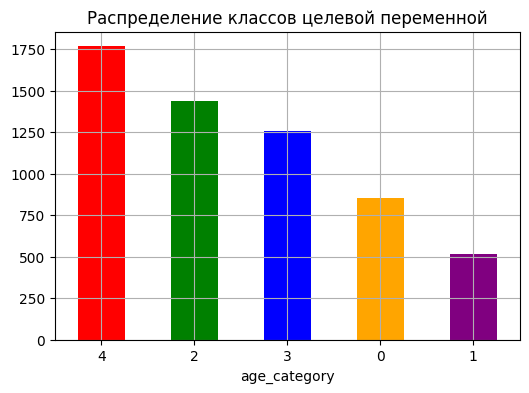

In [10]:
# Смотрим на целевую переменную
count = df_users ['age_category'].value_counts()
ratio = df_users ['age_category'].value_counts (normalize=True)*100
print (f'Количество пользователей каждого класса: {count}')
print (f'Процент каждого класса: {ratio}')

#Также визуализируем данные в виде столбчатой диаграммы
colors = ['red', 'green', 'blue', 'orange', 'purple']
count.plot(kind='bar', color=colors, rot=0)
plt.title('Распределение классов целевой переменной')
plt.grid ()
plt.show()

Целевая переменная неравномерно распределена между классами, так, максимальное число пользователей принадлежит к классу `4` - `1766 (30%)`, а минимальное к классу `1` - `514 (8%)`. Такой дисбаланс может сильно повлиять на качество модели, поэтому при разбиении данных на выборки мы будем использовать стритификацию, а во время обучения параметр `class_weight` - `balanced`.

#### <center><span style="color:black"> 2.3 Агрегирование таблицы visits </span> </center>

Прежде чем перейти к анализу корреляция и связей признаков и целевой переменной, нам необходимо объединить все таблицы в единое поле признаков. Но, перед этим, нужно аггрегировать таблицу `visits` по пользователям, преобразов фактический набор признаков в удобный для дальнейшего объединения.

Для этого используем метод `pivot_table` и посчитаем долю посещений каждой категории сайта пользователем, долю активностей пользователя на каждое время суток. Также, дополнительно рассчитаем следующие признаки: общее число событий каждого пользователя, количество дней активности, среднее число событий в день и самое активное время суток для каждого пользователя. 

In [11]:
# Сводная таблица: число посещений каждой категории на пользователя
pivot_cat = df_visits.pivot_table(
    index='user_id',
    columns='website_category',
    values='session_id',
    aggfunc='count',
    fill_value=0
)

# Нормализация по строкам (доля каждой категории)
ratio_cat = pivot_cat.div(pivot_cat.sum(axis=1), axis=0)
# Переименуем столбцы для наглядности
ratio_cat.columns = [col.lower().replace(' ', '_') for col in ratio_cat.columns]

In [12]:
# Сводная таблица по времени суток
pivot_time = df_visits.pivot_table(
    index='user_id',
    columns='daytime',
    values='session_id',
    aggfunc='count',
    fill_value=0
)

# Нормализация
ratio_daytime = pivot_time.div(pivot_time.sum(axis=1), axis=0)
ratio_daytime.columns = [col.lower().replace(' ', '_') for col in ratio_daytime.columns]

In [13]:
# Дополнительные признаки
total_events = df_visits.groupby('user_id').size()
n_days = df_visits.groupby('user_id')['date'].nunique()
events_per_day = total_events / n_days

# Самое активное время суток
daytime_count = df_visits.groupby(['user_id', 'daytime']).size().reset_index(name='count')
most_active_time = daytime_count.loc[daytime_count.groupby('user_id')['count'].idxmax()]
most_active_time = most_active_time[['user_id', 'daytime']].rename(columns={'daytime': 'most_active_daytime'}).set_index('user_id')['most_active_daytime']

# Сбор статистики
stats = pd.DataFrame({
    'total_events': total_events,
    'n_days_active': n_days,
    'events_per_day': events_per_day,
    'most_active_time': most_active_time
})

# Объединение всех признаков из логов
visits_features = ratio_cat.join(ratio_daytime).join(stats)

#### <center><span style="color:black"> 2.4 Объединение таблиц в единый датафрейм </span> </center>

После расчета всех признаков, объединим таблицы по идентификатору пользователя для дальнейшего анализа.

In [14]:
#Объединим все таблицы в единое признаковое пространство
df_merged = df_users.merge(visits_features, on='user_id', how='left')
df_merged = df_merged.merge(df_ads_activity, on='user_id', how='left')
df_merged = df_merged.merge(df_surf_depth, on='user_id', how='left')
df_merged = df_merged.merge(df_primary_device, on='user_id', how='left')
df_merged = df_merged.merge(df_cloud_usage, on='user_id', how='left')

In [15]:
#Посмотрим на правильность объединения
df_merged.info()

<class 'pandas.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 34 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5826 non-null   str    
 1   age_category      5826 non-null   int64  
 2   category_01       5826 non-null   float64
 3   category_02       5826 non-null   float64
 4   category_03       5826 non-null   float64
 5   category_04       5826 non-null   float64
 6   category_05       5826 non-null   float64
 7   category_06       5826 non-null   float64
 8   category_07       5826 non-null   float64
 9   category_08       5826 non-null   float64
 10  category_09       5826 non-null   float64
 11  category_10       5826 non-null   float64
 12  category_11       5826 non-null   float64
 13  category_12       5826 non-null   float64
 14  category_13       5826 non-null   float64
 15  category_14       5826 non-null   float64
 16  category_15       5826 non-null   float64
 17  catego

После объединения в датафрейме появился ряд пропуков. Это связано с отсутствием у некоторых пользователей информации о типе используемого устройства, глубине перехода и т.д. Данные пропуски необходимо обработать. В связи с дисбалансом классов нашей целевой переменной, удалять пропущенные значения мы не будем, чтобы еще сильнее не усугубить ситуацию, а заменим пропущенные значения на категорию `unknown` - неизвестно, т.к. пропуски присутствуют только в категориальных столбцах. 

Также у нас присутствует бинарный столбец, где присутствуют булевы значения - `cloud_usage`, в нем заменим пропуски на значени `False`.

In [16]:
# Обрабатываем пропуски
cols = ['ads_activity', 'surf_depth', 'primary_device']
for col in cols:
    df_merged [col] = df_merged [col].fillna('unknown')

df_merged ['cloud_usage'] = df_merged ['cloud_usage'].fillna(False)

In [17]:
# Посмотрим на наличие пропусков и дубликатов
print (f'Количество пропусков: {df_merged.isnull().sum()}')
print ('*'*50)
print (f'Количество дубликатов: {df_merged.duplicated().sum()}')

Количество пропусков: user_id             0
age_category        0
category_01         0
category_02         0
category_03         0
category_04         0
category_05         0
category_06         0
category_07         0
category_08         0
category_09         0
category_10         0
category_11         0
category_12         0
category_13         0
category_14         0
category_15         0
category_16         0
category_17         0
category_18         0
category_19         0
category_20         0
вечер               0
день                0
ночь                0
утро                0
total_events        0
n_days_active       0
events_per_day      0
most_active_time    0
ads_activity        0
surf_depth          0
primary_device      0
cloud_usage         0
dtype: int64
**************************************************
Количество дубликатов: 0


Пропусков и дубликатов в финальном датасете нет, он готов к дальнейшему анализу.

In [18]:
df_merged.sample(5)

,user_id,age_category,category_01,category_02,category_03,category_04,category_05,category_06,category_07,category_08,category_09,category_10,category_11,category_12,category_13,category_14,category_15,category_16,category_17,category_18,category_19,category_20,вечер,день,ночь,утро,total_events,n_days_active,events_per_day,most_active_time,ads_activity,surf_depth,primary_device,cloud_usage
773,a2cf-e52d7b0aa60506082aa0-41fae715,4,0.041985,0.000000,0.041985,0.057252,0.061069,0.072519,0.034351,0.030534,0.022901,0.068702,0.019084,0.068702,0.095420,0.019084,0.053435,0.022901,0.076336,0.041985,0.106870,0.064885,0.374046,0.332061,0.038168,0.255725,262,14,18.714286,вечер,умеренно,средне,смартфон,True
2621,f0ae-26e50fe7b68638ad958d-15d051ca,3,0.049645,0.063830,0.000000,0.099291,0.063830,0.056738,0.042553,0.028369,0.063830,0.120567,0.007092,0.007092,0.163121,0.049645,0.035461,0.035461,0.042553,0.014184,0.000000,0.056738,0.319149,0.446809,0.070922,0.163121,141,14,10.071429,день,редко,средне,смартфон,False
778,dbad-a11ca323e33e344d2da1-a41c0c26,1,0.087500,0.075000,0.156250,0.000000,0.087500,0.031250,0.100000,0.031250,0.018750,0.025000,0.025000,0.068750,0.043750,0.043750,0.006250,0.025000,0.000000,0.050000,0.037500,0.087500,0.393750,0.337500,0.075000,0.193750,160,14,11.428571,вечер,редко,средне,смартфон,True
4761,c681-b0eee133612407679554-adbad8a1,4,0.000000,0.055556,0.018519,0.041667,0.037037,0.078704,0.064815,0.023148,0.060185,0.055556,0.013889,0.115741,0.203704,0.009259,0.027778,0.023148,0.046296,0.000000,0.078704,0.046296,0.250000,0.402778,0.106481,0.240741,216,14,15.428571,день,часто,поверхностно,смартфон,True
5238,5c29-9556278d6f1cd91a310f-4c9c0d05,4,0.053333,0.030000,0.090000,0.010000,0.060000,0.053333,0.063333,0.090000,0.076667,0.010000,0.000000,0.026667,0.073333,0.030000,0.030000,0.056667,0.050000,0.080000,0.046667,0.070000,0.320000,0.380000,0.073333,0.226667,300,14,21.428571,день,часто,поверхностно,ноутбук,False


#### <center><span style="color:black"> 2.5 Анализ категориальных признаков </span> </center>

В финальном датасете присутствует ряд категориальных признаков. Проанализируем их: посмотрим на количество уникальных значений, а также посмотрим основные статистики, посмотрим на частоту категорий и т.д.

Посмотрим на уникальные значения в каждом категориальном признаке и их количество, чтобы решить каким способом провести кодирование на этапе предобработки данных.

In [19]:
# Выводим количество уникальных значений среди категориальных признаков
for col in ['most_active_time', 'ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']:
    print (f'Количество уникальных значений в {col}: {df_merged [col].nunique()}')
    print ()

Количество уникальных значений в most_active_time: 3

Количество уникальных значений в ads_activity: 6

Количество уникальных значений в surf_depth: 4

Количество уникальных значений в primary_device: 5

Количество уникальных значений в cloud_usage: 2



In [ ]:
# Выведем основные статистики кат. данных
df_merged.select_dtypes (include=['object']).describe()

,user_id,most_active_time,ads_activity,surf_depth,primary_device,cloud_usage
count,5826,5826,5826,5826,5826,5826
unique,5826,3,6,4,5,2
top,f545-8c95aefe8d3e5548a689-a5b2fd39,день,умеренно,средне,смартфон,True
freq,1,3087,1824,2435,3083,2951


Количество уникальных значений в категориальных признаках меньше `10`, поэтому на этапе предобработки данных мы будем использовать `OneHotEncoder` для кодирования данных колонок. Этот же метод используем для бинарнго признака `cloud_usage`. 

По частоте, в каждом признаке присутствует наиболее часто встречающаяся категория, но при этом нет значений, которые могли быть близки к моде. Следовательно, все категории могут в той, или иной степени влиять на обучение и предсказательную способность модели. На данном этапе оставляем все признаки.

Колонку `user_id` удалим, чтобы она не мешала дальнейшему анализу, в обучении модели же уникальные идентификатору не несут никакой информации.

In [21]:
#Удаляем уникальные идентификаторы
df_merged = df_merged.drop (columns = 'user_id')

#### <center><span style="color:black"> 2.6 Анализ цифровых признаков </span> </center>

Теперь посмотрим на основные статистики и диаграмы по числовым признакам. Оценим распределения значений и наличие выбросов в данных. Для этого построим гистограммы и `ящики с усам` - боксплоты, а также составим общий график для оценки масштаба признаков.

In [22]:
# Выведем основные статистики почисловым признакам
df_merged.select_dtypes (include=np.number).describe()

,age_category,category_01,category_02,category_03,category_04,category_05,category_06,category_07,category_08,category_09,category_10,category_11,category_12,category_13,category_14,category_15,category_16,category_17,category_18,category_19,category_20,вечер,день,ночь,утро,total_events,n_days_active,events_per_day
count,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000,5826.000000
mean,2.440439,0.049933,0.041647,0.065480,0.048701,0.057005,0.053715,0.051322,0.052678,0.050884,0.049334,0.036852,0.047742,0.064447,0.043433,0.048679,0.043211,0.046991,0.048007,0.051999,0.047940,0.358199,0.364961,0.078108,0.198733,180.225712,13.998627,12.874047
std,1.381287,0.031238,0.029358,0.051979,0.027860,0.029300,0.028035,0.029239,0.032203,0.028265,0.028688,0.027020,0.030454,0.057089,0.029823,0.028532,0.028434,0.029080,0.031702,0.028733,0.029135,0.048836,0.045206,0.024633,0.038134,75.186802,0.037034,5.369733
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.214286,0.217822,0.000000,0.049505,100.000000,13.000000,7.142857
25%,2.000000,0.026786,0.018779,0.020000,0.029304,0.036776,0.033898,0.030000,0.029126,0.030422,0.029412,0.016048,0.024845,0.008130,0.020000,0.028846,0.021277,0.025641,0.024540,0.031059,0.026667,0.324324,0.335058,0.060606,0.172575,124.000000,14.000000,8.857143
50%,3.000000,0.048630,0.039697,0.060241,0.046296,0.055215,0.051282,0.050000,0.050533,0.049417,0.047619,0.033528,0.046403,0.056936,0.041237,0.047619,0.040381,0.045161,0.044329,0.050000,0.045595,0.357542,0.365385,0.076142,0.196765,167.000000,14.000000,11.928571
75%,4.000000,0.070000,0.060606,0.101695,0.066169,0.075885,0.070866,0.070000,0.074286,0.068801,0.066865,0.054217,0.068182,0.102795,0.062850,0.067227,0.060309,0.064852,0.067797,0.070000,0.066667,0.391304,0.395664,0.093407,0.223863,213.000000,14.000000,15.214286
max,4.000000,0.182927,0.180556,0.261438,0.188119,0.172131,0.171053,0.165414,0.188679,0.188034,0.217822,0.174603,0.178571,0.295918,0.190000,0.198020,0.160305,0.187970,0.195804,0.180000,0.179688,0.530000,0.532710,0.198020,0.360000,839.000000,14.000000,59.928571


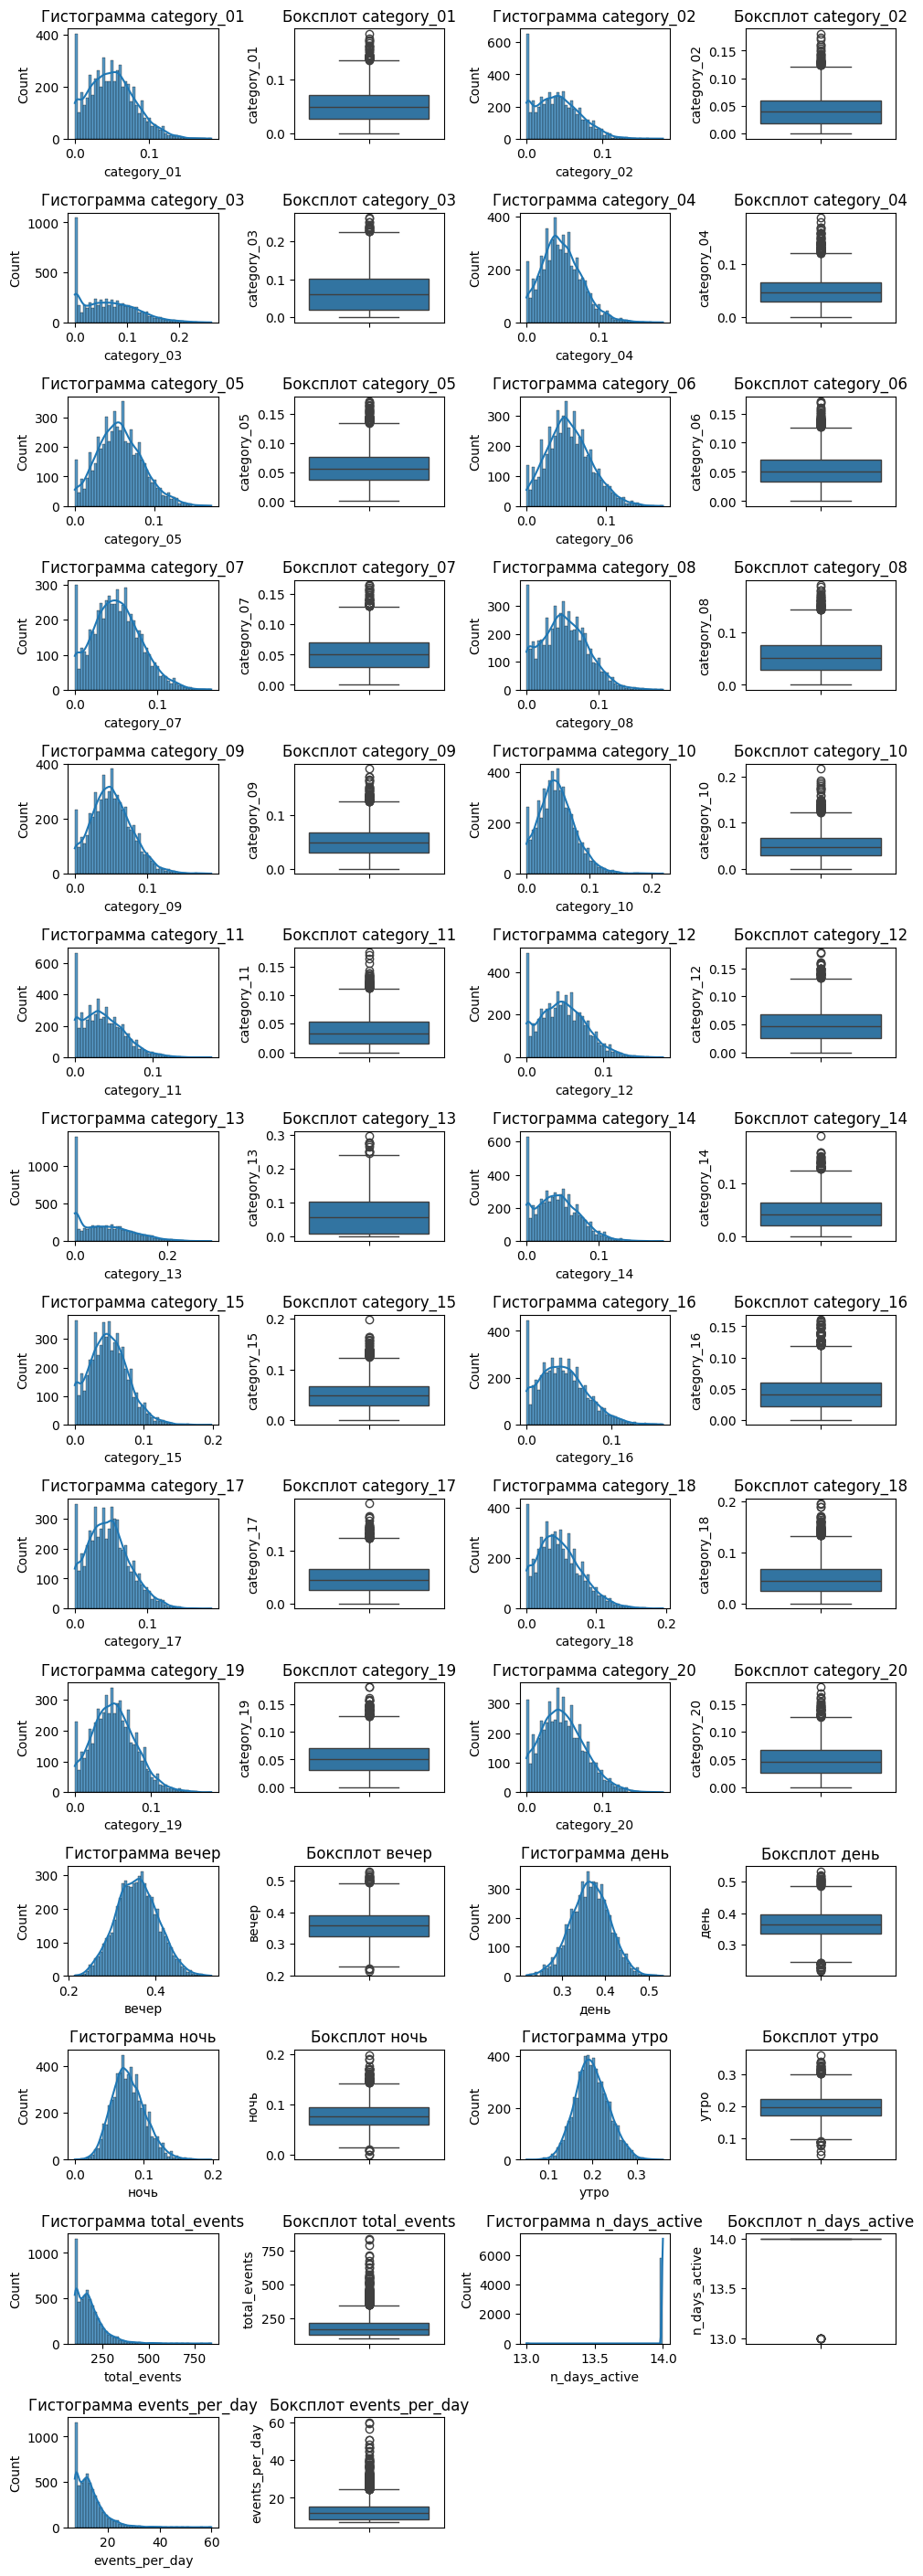

In [23]:
#Далее построим гистограммы и боксплоты всех числовых признаков, чтобы оценить наличие выбросов и распределений
# Получаем список числовых признаков
num_features = ['category_01', 'category_02', 'category_03', 'category_04', 'category_05', 'category_06', 'category_07', 'category_08', 
                'category_09', 'category_10', 'category_11', 'category_12', 'category_13', 'category_14', 'category_15', 'category_16', 
                'category_17', 'category_18', 'category_19', 'category_20', 'вечер', 'день', 'ночь', 'утро', 'total_events', 'n_days_active', 'events_per_day']
n_features = len (num_features)
# Подсчет необходимого количества строк
rows = n_features
cols = 4
plt.figure (figsize=(10, rows*2))

# Рисуем графики
for idx, feature in enumerate (num_features):
    plt.subplot (rows, cols, idx*2+1) 
    sns.histplot (df_merged [feature], bins = 50, alpha = 0.75, kde = True)
    plt.title (f'Гистограмма {feature}')

    plt.subplot (rows, cols, idx*2+2)
    sns.boxplot (df_merged [feature], orient='v')
    plt.title (f'Боксплот {feature}')

plt.tight_layout()
plt.show()

Сразу построим диаграмму сравнения боксплотов, для визуализации разницы масштабов признаков.

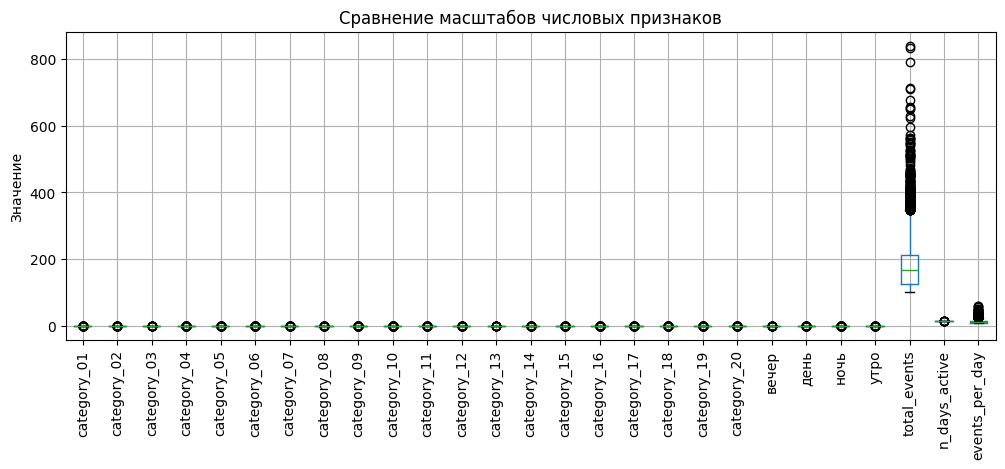

In [24]:
#Визуализируем масштаб данных
plt.figure (figsize= (12, 4))

# Строим boxplot (диаграмму размаха) для всех признаков
df_merged.boxplot (column = num_features, rot = 90)
plt.title ('Сравнение масштабов числовых признаков')
plt.ylabel ('Значение')
plt.show ()

Цифровые признаки в большинстве своем имеют `нормальное распределение` с небольшой левой ассиметрией (сосредоточенной, в основном, в области `0`). Два выделяющихся на фоне остальных признака, это `total_events` и `events_per_day`, они имеют яркую левую вссиметрию с длинным правым хвостом. Ассиметрии связаны с выбросами, которые в рамках текущей задачи являются нормой (некоторые пользователи могут проводить в интернете гораздо больше времени, чем остальные, что и обуславливает большее количество логов), поэтому мы нет будем фильтровать их, так как помимо важной информации, которую они могут нести дл модели, экстремумы могут сокаратить число дисбалансных классов, ухудшив тем самым обучение моделей.

Помимо этого, мы видим, что признак `n_days_active` практически целиком (кроме одного значения) равен `14.0`, что делает его константным и не несущим потенциально важной информации для нашей модели. Его мы удалим.

На графике сравнения масштабов признаков выделяются два: `total_events` `events_per_day`. Это логично, так как оба эти признака несут информацию о количестве событий пользователей, что явно больше в числовом эквиваленте, чем доли остальных признаков. В связи с этим, данные колонки мы масштабируем на этапе предобработки с помощью `StandardScaler`, что поможет нам сгладить влияние экстремальных значений и их вес на модель.

In [25]:
#Удаляем константный признак n_days_active
df_merged = df_merged.drop(columns = 'n_days_active')

#### <center><span style="color:black"> 2.7 Корреляции </span> </center>

После проверки категориальных и числовых признаков, мы приступаем к анализу их корреляция с целевой переменной, а также между собой. Этот этап исследования позволит нам выявить потенциально бесполезные признаки, которые можно будет удалить из финального поля для ускорения работы модели. 

Сначала посмотрим на корреляции целевой переменной с каждым признаком. Для этого будем использовать специальный инструмент `phik`. Построим с помощью него матрицу и создадим наглядную тепловую карту.

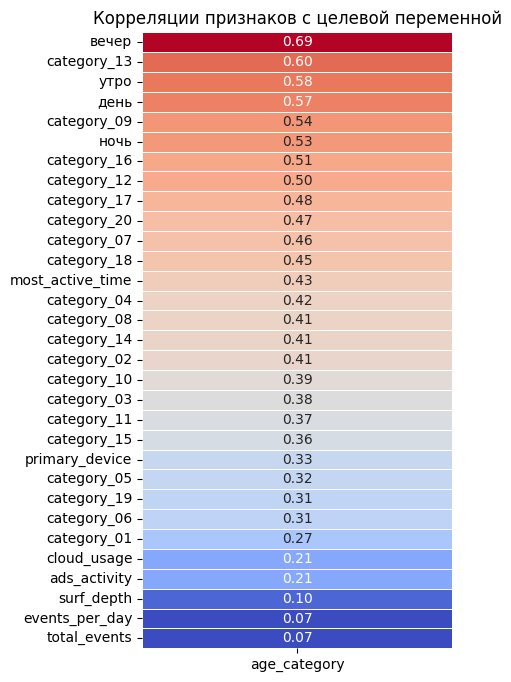

In [26]:
#Создаем матрицу корреляций
correlation_matrix = df_merged.phik_matrix(interval_cols = num_features)
age_correlations_all = correlation_matrix.loc[correlation_matrix.index != 'age_category'][['age_category']].sort_values(by='age_category', ascending=False)
#Для наглядности построим тепловую карту на основе нашей матрицы
plt.figure (figsize=(4, 8))
data_heatmap = age_correlations_all

sns.heatmap (
    data_heatmap,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm',  
    linewidths=0.5, 
    cbar=False
)
plt.title ('Корреляции признаков с целевой переменной')
plt.show ()

Многие признаки оказывают достаточно сильное влияние на целевую переменную и могут быть очень полезны во время обучения моделей. Исходя из корреляционной матрицы, самое сильное влияние оказывает признак `вечер`. На втором, третьем и четвертом местах `category_13`, `утро` и `день` соответственно. Далее признаки постепенно опускаются вплоть до минимальных значений корреляции: `0.07` у `events_per_day` и `total_events`.

Глядя на общую картину, можно предположить, что решающее больше влияние на целевую переменную оказывают признаки характеризующие время суток в которое пользователи запускают сессии и определенные категории, которые их интересуют. Это логично, так как, можно предположить, что более молодые пользователи предпочитают более позднее время суток для интернет активности, а возрастные - более раннее. Тоже касается и категорий. Для разного возраста характерны разные интересы и категории сайтов.

На данном этапе оставим все признаки и посмотри далее на корреляции их между собой, чтобы не пропустить возможные мультиколлинеарные поля.

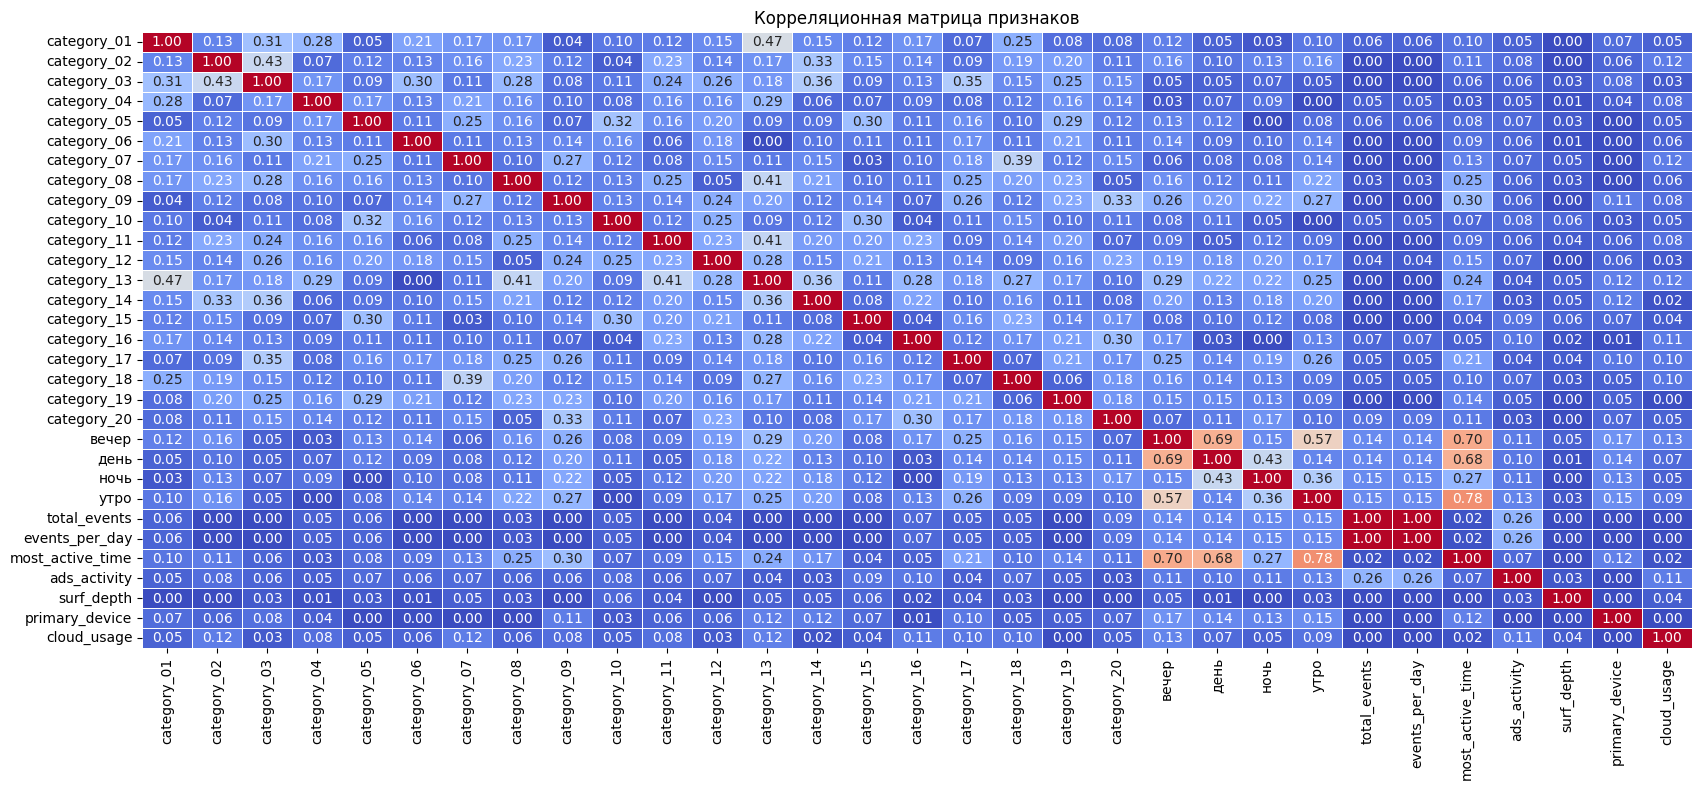

In [27]:
# Визуализируем полную матрицу корреляций
plt.figure (figsize=(20, 8))
data_heatmap = correlation_matrix.loc[:, correlation_matrix.columns != 'age_category'].loc[correlation_matrix.index != 'age_category']

sns.heatmap (
    data_heatmap,
    annot=True, 
    fmt='.2f', 
    cmap='coolwarm',  
    linewidths=0.5, 
    cbar=False
)
plt.title ('Корреляционная матрица признаков')
plt.show ()

Критических корреляций между признаками нет. Есть достаточно высокие показатели между `most_active_time` и временем суток, но пока что мы оставим эти признаки. Возможно часть из них уберется на этапе отбора признаков.

#### <center><span style="color:black"> 2.8 Функция для продакшна </span> </center>

В заключение исследовательского анализа данных, мы составим полноценную функцию, которая будет собирать данные из всех исходных таблиц в единое признаковое пространство `df_merged`, которое можно будет использовать в дальнейшем пайплайне.

In [28]:
def create_df_merged(users_path, visits_path, ads_path, surf_path, device_path, cloud_path):
    """Объединяет все исходные таблицы в единое признаковое пространство. Возвращает DataFrame с признаками"""
    # 1. Загрузка
    df_users = pd.read_csv(users_path)
    df_visits = pd.read_csv(visits_path)
    df_ads_activity = pd.read_csv(ads_path)
    df_surf_depth = pd.read_csv(surf_path)
    df_primary_device = pd.read_csv(device_path)
    df_cloud_usage = pd.read_csv(cloud_path)
    
    # 2. Обработка дубликатов
    df_users = df_users.drop_duplicates (keep = 'first').reset_index(drop=True)
    df_visits = df_visits.drop_duplicates (keep = 'first').reset_index(drop=True)
    df_ads_activity = df_ads_activity.drop_duplicates (keep = 'first').reset_index(drop=True)
    
    # 3. Агрегация visits
    # Сводная таблица: число посещений каждой категории на пользователя
    pivot_cat = df_visits.pivot_table(
        index='user_id',
        columns='website_category',
        values='session_id',
        aggfunc='count',
        fill_value=0
    )
    # Нормализация по строкам (доля каждой категории)
    ratio_cat = pivot_cat.div(pivot_cat.sum(axis=1), axis=0)
    # Переименуем столбцы для наглядности
    ratio_cat.columns = [col.lower().replace(' ', '_') for col in ratio_cat.columns]
    # Сводная таблица по времени суток
    pivot_time = df_visits.pivot_table(
        index='user_id',
        columns='daytime',
        values='session_id',
        aggfunc='count',
        fill_value=0
    )
    # Нормализация
    ratio_daytime = pivot_time.div(pivot_time.sum(axis=1), axis=0)
    ratio_daytime.columns = [col.lower().replace(' ', '_') for col in ratio_daytime.columns]
    # Дополнительные признаки
    total_events = df_visits.groupby('user_id').size()
    n_days = df_visits.groupby('user_id')['date'].nunique()
    events_per_day = total_events / n_days
    # Самое активное время суток
    daytime_count = df_visits.groupby(['user_id', 'daytime']).size().reset_index(name='count')
    most_active_time = daytime_count.loc[daytime_count.groupby('user_id')['count'].idxmax()]
    most_active_time = most_active_time[['user_id', 'daytime']].rename(columns={'daytime': 'most_active_daytime'}).set_index('user_id')['most_active_daytime']
    # Сбор статистики
    stats = pd.DataFrame({
        'total_events': total_events,
        'n_days_active': n_days,
        'events_per_day': events_per_day,
        'most_active_time': most_active_time
    })
    # Объединение всех признаков из логов
    visits_features = ratio_cat.join(ratio_daytime).join(stats)    
    # 4. #Объединим все таблицы в единое признаковое пространство
    df_merged = df_users.merge(visits_features, on='user_id', how='left')
    df_merged = df_merged.merge(df_ads_activity, on='user_id', how='left')
    df_merged = df_merged.merge(df_surf_depth, on='user_id', how='left')
    df_merged = df_merged.merge(df_primary_device, on='user_id', how='left')
    df_merged = df_merged.merge(df_cloud_usage, on='user_id', how='left')
    
    
    # 6. Заполнение пропусков
    # Обрабатываем пропуски
    cols = ['ads_activity', 'surf_depth', 'primary_device']
    for col in cols:
        df_merged [col] = df_merged [col].fillna('unknown')
    
    df_merged ['cloud_usage'] = df_merged ['cloud_usage'].fillna(False)
    
    #7.Удаляем ненужные колонки
    df_merged = df_merged.drop(columns = ['n_days_active', 'user_id'])
    
    return df_merged

#### <center><span style="color:black"> 2.9 Выводы по EDA </span> </center>

После проведенного исследовательского анализа данных, можно сделать следующие промежуточные выводы:

1. Предоставленные данные, в виде `5` таблиц соответствуют заявленным категориям и типам данных, но требуют некоторых агрегаций для последующего обучения моделей.
2. В данных наблюдается сильный дисбаланс классов, что ставит перед нами наобходимость использовать `стратификацию` при разбиении данных на выборки, а также параметр `class_weight` - `balanced`, где это возможно при тренировки моделей.
3. В некоторых таблицах: `df_users`, `df_visits` и `df_ads_activity` присутствовали полные дубликаты, которые были удалены.
4. Таблица `df_ visits` содержащие логи активностей каждого пользователя была определенным образом агрегирована. Были выделены, для каждого пользователя, доли его активностей в каждой категории сайтов, общее и среднее количество сессий в день и самое активное время суток, после чего все исходные таблицы объединили для формирования общего поля признаков, которое подходит для дальнейшего обучения моделей.
5. В рамках общего пространства признаков, представленного в виде единого датафрейма, была проведена обработка пропусков. Значения отсутствовали только в категориальных колонках, поэтому все пустые места были заменены на значение `unknown`.
6. Анализ категориальных признаков показал отсутствие большого количества уникальных значений, в связи с чем было решено кодировать все категориальные признаки с помощью `OneHotEncoder`.
7. Числовые признаки в большинстве своем имеют нормальное распределение с небольшим скосом в сторону левой ассиметрии. Выбросы не критичны, их фильтрация не требуется и, в рамках текущей задачи, может повлиять на достоверность предсказаний моделей. Но, в связи с экстремальным разбросом масштаба значений, было решено провести масштабирование экстремальных числовых признаков методом `StandardScaler`.
6. Был проведен корреляционный анализ признаков с целевой переменной, а также всех признаков между собой. Выявлено сильное влияние времени суток на целевую переменную и некоторых категорий сайтов. Сильная мультиколинеарность среди признаков не выявлена, решено оставить все поля до более углубленного их отбора.

## <center> <span style="color:black"> 3. Разделение данных на выборки </span> </center> 

Перед обучением модели нам необходимо отделить целевую переменную от признаков, а также поделить данные на выборки: тренировочную, на которой мы будем тренировать модели и валидировать, а также тестовую, на которой будет проходить финальное тестирование.

In [29]:
# Выделяем из датасета целевую переменную и признаки
X = df_merged.drop (columns=['age_category'])
y = df_merged ['age_category']
# Делим данные на две выборки со стратификацией
X_train_val, X_test, y_train_val, y_test = train_test_split (
    X, 
    y,
    test_size= 0.2,
    stratify=y,
    random_state=RANDOM_SEED
)
# Проверяем выборки
print("X_train:", X_train_val.shape)
print("y_train:", y_train_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape) 

X_train: (4660, 31)
y_train: (4660,)
X_test: (1166, 31)
y_test: (1166,)


Проверим распределения классов целевой переменной в выборках.

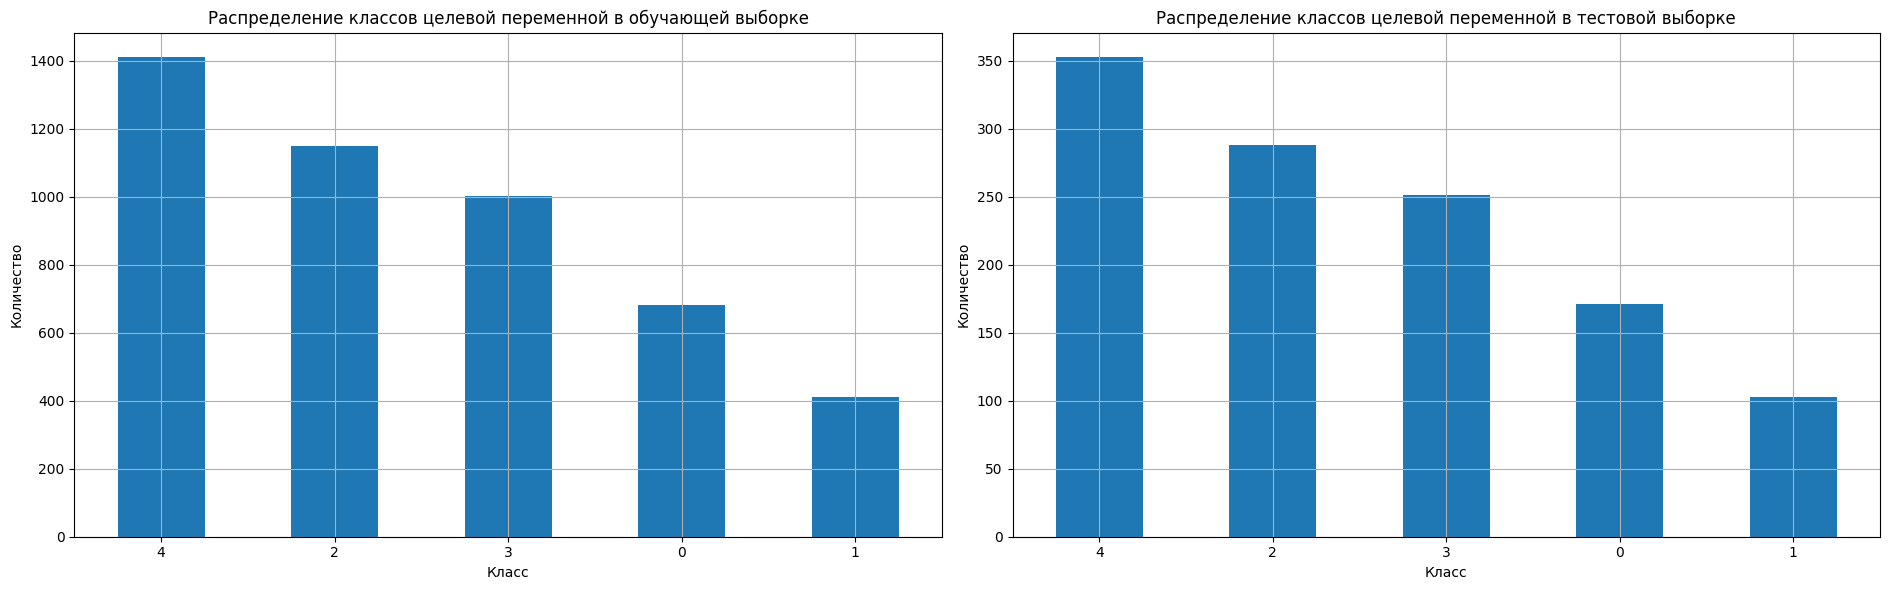

In [30]:
# Смотрим на распределения классов целевой переменной в тестовой и обучающей выборках
plt.figure(figsize= (19, 6))
plt.subplot (1, 2, 1)
y_train_val.value_counts().plot (
    kind = 'bar',
    rot = 0,
    xlabel = 'Класс',
    ylabel = 'Количество'
)
plt.title ('Распределение классов целевой переменной в обучающей выборке')
plt.grid()

plt.subplot (1, 2, 2)
y_test.value_counts().plot (
    kind = 'bar',
    rot = 0,
    xlabel = 'Класс',
    ylabel = 'Количество'
)
plt.title ('Распределение классов целевой переменной в тестовой выборке')
plt.grid()
plt.tight_layout()
plt.show()

Благодаря стратификации распределения классов целевой переменной в выборках идентичное. Можно приступать к построению пайплайнов.

## <center> <span style="color:black"> 4. Предобработка данных </span> </center> 

Далее подготовим пайплайны по обработке цифровых и категориальных признаков. 

Числовые признаки мы масштабируем с помощью `StandardScaler`, а категориальные закодируем методом `OneHotEncoder`.

In [31]:
#Определяем цифровые и категориальные признаки
num_features = ['category_01', 'category_02', 'category_03', 'category_04', 'category_05', 'category_06', 'category_07', 'category_08', 
                'category_09', 'category_10', 'category_11', 'category_12', 'category_13', 'category_14', 'category_15', 'category_16', 
                'category_17', 'category_18', 'category_19', 'category_20', 'вечер', 'день', 'ночь', 'утро', 'total_events', 'events_per_day']
cat_features = ['most_active_time', 'ads_activity', 'surf_depth', 'primary_device', 'cloud_usage']
# Создаем экземпляры классов
one_hot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Формируем пайплайны
# Чиловой пайплайн
num_pipeline = Pipeline (steps = [
    ('масштабирование', StandardScaler ())
])
# Категориальный пайплайн с OneHot
cat_pipeline = Pipeline (steps = [
    ('кодирование признаков', one_hot)
])
#Напишем финальный трансформер
preprocessor = ColumnTransformer (transformers= [
    ('num', num_pipeline, num_features),
    ('cat', cat_pipeline, cat_features)
])

## <center> <span style="color:black"> 5. Обучение и оценка базовой модели </span> </center> 

#### <center><span style="color:black"> 5.1 Обучение DummyClassifier </span> </center>

Теперь обучим базовую модель, тобы обозначить начальный уровень работы модели, с которым будем сравнивать наиболее сложные. В качестве базовой модели будем использовать `DummyClassifier`. 

В качестве основной метрики оценки будем использовать `F1-меру` с макроагрегацией по классам, а в качестве дополнительных метрик: `precision-macro` и `recall-macro`. Это позволит нам полноценно оценить точность и полноту модели, видеть где модель работает хорошо, а где ошибается. Также, мы будем использовать макроагрегацию по классам, т.к. нам важно правильно оценить способность модели определять каждую возрастную группу, чтобы рекламируемый контент ей соответствовал, а метод макроагрегации поможет не недооценивать малочисленные классы.

In [32]:
# Задаем кол-во фолдов для кросс-валидации
N_FOLDS = 5
# Проведем кросс валидацию базовой модели - Dummy Classifier
kfold = StratifiedKFold (n_splits = N_FOLDS, shuffle = True, random_state = RANDOM_SEED)
scoring = ['f1_macro', 'precision_macro', 'recall_macro']
#Выполняем кросс-валидаию базовой модели
cv_results_base = cross_validate (
    estimator = OneVsRestClassifier(estimator=DummyClassifier(strategy = 'stratified', random_state=RANDOM_SEED)),
    X = X_train_val,
    y = y_train_val,
    scoring = scoring,
    cv = kfold
)
base_means = {
    'F1': round(np.mean(cv_results_base['test_f1_macro']), 3),
    'Precision': round(np.mean(cv_results_base['test_precision_macro']), 3),
    'Recall': round(np.mean(cv_results_base['test_recall_macro']), 3)
}
print ('Результаты базовой модели')
print ('*'*50)
print (f"F1: {base_means ['F1']}")
print (f"Precision: {base_means ['Precision']}")
print (f"Recall: {base_means ['Recall']}")


#Создадим датафрейм и добавим в него данные базовой модели для финального сравнения
results_df = pd.DataFrame(index=['Dummy Classifier', 'Base Logistic Regression', 'Base SVC'])
# Добавляем результаты первой модели (Dummy Classifier)
results_df.at['Dummy Classifier', 'F1'] = base_means['F1']
results_df.at['Dummy Classifier', 'Precision'] = base_means['Precision']
results_df.at['Dummy Classifier', 'Recall'] = base_means['Recall']

Результаты базовой модели
**************************************************
F1: 0.094
Precision: 0.141
Recall: 0.202


Базовая модель, как и ожидалось работает очень плохо, но она будет служить стартовой точкой для дальнейшего улучшения моделей.

#### <center><span style="color:black"> 5.2 Обучение Logistic Regression </span> </center>

Далее обучим `LogisticRegression`. Применим параметр `class_weight` - `balanced` для контроля весов классов, которые в нашем случае находятся в сильном дисбалансе. Проведем ее кросс-валидацию и посмотрим на метрики. Для первого обучения остальные параметры модели оставим базовыми.

In [33]:
#Создаем пайплайн с логистической регрессией
pipeline_lr = Pipeline (steps = [
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight= 'balanced', random_state=RANDOM_SEED))
])
#Выполняем кросс-валидаию Логистической регрессии
cv_results_lr = cross_validate (
    estimator = OneVsRestClassifier(estimator=pipeline_lr),
    X = X_train_val,
    y = y_train_val,
    scoring = scoring,
    cv = kfold
)
lr_means = {
    'F1': round(np.mean(cv_results_lr['test_f1_macro']), 3),
    'Precision': round(np.mean(cv_results_lr['test_precision_macro']), 3),
    'Recall': round(np.mean(cv_results_lr['test_recall_macro']), 3)
}
print ('Результаты Logistic Regression')
print ('*'*50)
print (f"F1: {lr_means ['F1']}")
print (f"Precision: {lr_means ['Precision']}")
print (f"Recall: {lr_means ['Recall']}")

# Добавляем результаты второй модели (Logistic Regression)
results_df.at['Base Logistic Regression', 'F1'] = lr_means['F1']
results_df.at['Base Logistic Regression', 'Precision'] = lr_means['Precision']
results_df.at['Base Logistic Regression', 'Recall'] = lr_means['Recall']

Результаты Logistic Regression
**************************************************
F1: 0.803
Precision: 0.801
Recall: 0.805


Логистическая регрессия показывает значительно лучшие результаты. `F1` метрика составляет `0.803`, это достаточно хороший показатель. В совокупности с высокими `Precision` и `Recall`, можно смело сказать, что модель правильно классифицирует пользователей по возрастным категориям в 80% случаев (с учётом как пропущенных целей, так и ложных срабатываний). Требование заказчика (≥0.75) выполнено с запасом.

#### <center><span style="color:black"> 5.3 Обучение SVC </span> </center>

Обучим также базовую модель `SVC`. Данная модель может лучше находить закономерсти в рамках нашей задачи. Обучим классический `SVC` с линейным ядром и сбалансированным `class_weight`.

In [34]:
#Создаем пайплайн с методом опорных векторов
pipeline_svc = Pipeline (steps = [
    ('preprocessor', preprocessor),
    ('model', SVC(kernel = 'linear', probability = False, random_state=RANDOM_SEED, class_weight='balanced'))
])
#Выполняем кросс-валидаию Логистической регрессии
cv_results_svc = cross_validate (
    estimator = OneVsRestClassifier(estimator=pipeline_svc),
    X = X_train_val,
    y = y_train_val,
    scoring = scoring,
    cv = kfold
)
svc_means = {
    'F1': round(np.mean(cv_results_svc['test_f1_macro']), 3),
    'Precision': round(np.mean(cv_results_svc['test_precision_macro']), 3),
    'Recall': round(np.mean(cv_results_svc['test_recall_macro']), 3)
}
print ('Результаты SVC')
print ('*'*50)
print (f"F1: {svc_means ['F1']}")
print (f"Precision: {svc_means ['Precision']}")
print (f"Recall: {svc_means ['Recall']}")

# Добавляем результаты третьей модели (SVC)
results_df.at['Base SVC', 'F1'] = svc_means['F1']
results_df.at['Base SVC', 'Precision'] = svc_means['Precision']
results_df.at['Base SVC', 'Recall'] = svc_means['Recall']

Результаты SVC
**************************************************
F1: 0.806
Precision: 0.804
Recall: 0.808


`SVC` показывает практически идентичные результаты с логистической регрессией. Небольшое преимущество в 0.3 процентных пункта по всем метрикам незначительно, но показатели могут значительно улучшиться при использовании других ядер и гиперпараметров.

In [35]:
# Посмотрим на таблицу с результатами
results_df = results_df.T
display(results_df)

,Dummy Classifier,Base Logistic Regression,Base SVC
F1,0.094,0.803,0.806
Precision,0.141,0.801,0.804
Recall,0.202,0.805,0.808


Исходя из результатов метрик базовых моделей, можно сделать вывод, что обе модели уже достаточно хорошо справляются с поставленной задачей и превышают требуемы порог в `0.75`. Но, попробуем сделать их еще точнее проведя глубокий отбор признаков, а также выполнив подбор гиперпараметров. Это позволит нам выявить лучшие комбинации параметров моделей и значительно улучшить результат абсолютно минимизировав количество ложных срабатываний.

## <center> <span style="color:black"> 6. Отбор признаков </span> </center> 

На этапе предварительного анализа мы уже провели поверхностный отбор некоторых признаков и избавились от бесполезных полей в нашем датафрейме. Теперь же применим более глубокие методы поиска неинформативных для моделей признаков, а именно обратный отбор, т.к. анализ показал, что большинство признаков достаточно сильно коррелируют с цеелвой переменной попробуем оставить в модели 28 признаков, исключив те, phik коэффициент которых ниже единицы.

In [36]:
# Отбираем признаки RFE
# Предварительный fit() для получения имён признаков
X__train_val_processed = preprocessor.fit_transform(X_train_val)
feature_names = preprocessor.get_feature_names_out()

estimator = LogisticRegression (random_state=RANDOM_SEED)
selector = SequentialFeatureSelector(estimator, n_features_to_select=28, direction='backward', cv=5)
selector.fit(X__train_val_processed, y_train_val)
selected_idx = selector.support_
selected_features = np.array(feature_names)[selected_idx]

feature_names_all = list(preprocessor.get_feature_names_out())
selected_indices = [feature_names_all.index(f) for f in selected_features]

feature_selector = FunctionTransformer(lambda X: X[:, selected_indices], validate=False)

#Сформируем функцию для обучения разных моделей
def build_pipeline (model):
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),   
        ('feature_selection', feature_selector),
        ('model', OneVsRestClassifier(estimator=model))   
])
    return full_pipeline

После отбора признаков, проведем подбор гиперпараметров.

## <center> <span style="color:black"> 7. Подбор гиперпараметров моделей </span> </center> 

Определим две сетки гиперпараметров для `LogisticRegression` и для `SVC`.

In [37]:
#Сетка параметров для LogisticRegression
param_grid_lr = {
    'model__estimator__C': [0.01, 0.1, 1, 10]
}
# Сетка параметров для SVC
param_grid_svc = [
    # Линейное ядро: только C
    {
        "model__estimator__kernel": ["linear"],
        "model__estimator__C": [0.1, 1, 10]  # категории: низкое, среднее, высокое
    },
    # Poly: перебираем только разумные значения gamma, degree и coef0
    {
        "model__estimator__kernel": ["poly"],
        "model__estimator__C": [0.1, 1, 10],
        "model__estimator__gamma": ["scale", "auto"],
        "model__estimator__degree": [2, 3, 4],       
        "model__estimator__coef0": [0.0, 0.5, 1.0]   
    },
    # RBF: только C и gamma
    {
        "model__estimator__kernel": ["rbf"],
        "model__estimator__C": [0.1, 1, 10],
        "model__estimator__gamma": ["scale", "auto"]
    },
    # Sigmoid: аналогично poly, но без degree
    {
        "model__estimator__kernel": ["sigmoid"],
        "model__estimator__C": [0.1, 1, 10],
        "model__estimator__gamma": ["scale", "auto"],
        "model__estimator__coef0": [0.0, 0.5, 1.0]
    }
] 

In [38]:
# Проводим поиск гиперпараметров Логистической регрессии
grid_lr = GridSearchCV(
    estimator=build_pipeline(LogisticRegression(class_weight='balanced', random_state=RANDOM_SEED)),
    param_grid= param_grid_lr,
    cv=kfold,             
    scoring='f1_macro', 
    n_jobs=-1,        
    verbose=1         
)
grid_lr.fit(X_train_val, y_train_val)

# Сохраним лучшую комбинацию гиперпараметров в отдельную переменную
best_params_lr = grid_lr.best_params_

# Сохраним лучшую модель в отдельную переменную
best_estimator_lr = grid_lr.best_estimator_

# Сохраним лучший результат average_precision в отдельную переменную
best_score_lr = round(grid_lr.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_lr)
print("Лучшая модель:", best_estimator_lr)
print("Лучший средний результат f1_macro на кросс-валидации:", best_score_lr)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Лучшие гиперпараметры: {'model__estimator__C': 1}
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('масштабирование',
                                                                   StandardScaler())]),
                                                  ['category_01', 'category_02',
                                                   'category_03', 'category_04',
                                                   'category_05', 'category_06',
                                                   'category_07', 'category_08',
                                                   'category_09', 'category_10',
                                                   'category_11', 'category_12',
                                                   'category_13', 'category_14',
                                            

In [39]:
# Проводим поиск гиперпараметров SVC
grid_svc = GridSearchCV(
    estimator=build_pipeline(SVC(probability = False, random_state=RANDOM_SEED, class_weight='balanced')),
    param_grid= param_grid_svc,
    cv=kfold,             
    scoring='f1_macro', 
    n_jobs=-1,        
    verbose=1         
)
grid_svc.fit(X_train_val, y_train_val)

# Сохраним лучшую комбинацию гиперпараметров в отдельную переменную
best_params_svc = grid_svc.best_params_

# Сохраним лучшую модель в отдельную переменную
best_estimator_svc = grid_svc.best_estimator_

# Сохраним лучший результат average_precision в отдельную переменную
best_score_svc = round(grid_svc.best_score_, 3)

# Вывод лучших гиперпараметров, модели и результата
print("Лучшие гиперпараметры:", best_params_svc)
print("Лучшая модель:", best_estimator_svc)
print("Лучший средний результат f1_macro на кросс-валидации:", best_score_svc)

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Лучшие гиперпараметры: {'model__estimator__C': 1, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'rbf'}
Лучшая модель: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('масштабирование',
                                                                   StandardScaler())]),
                                                  ['category_01', 'category_02',
                                                   'category_03', 'category_04',
                                                   'category_05', 'category_06',
                                                   'category_07', 'category_08',
                                                   'category_09', 'category_10',
                                                   'category_11', 'category_12',
                                                   '

In [40]:
# Результаты GridSearchCV для логистической регрессии
results_lr = pd.DataFrame(grid_lr.cv_results_)

# Результаты GridSearchCV для SVC
results_SVC = pd.DataFrame(grid_svc.cv_results_)

# Объединяем оба фрейма
combined_results = pd.concat([results_lr, results_SVC], ignore_index=True)

# Отсортируем по среднему значению метрики (среднее значение f1)
top_models = combined_results.sort_values(by='mean_test_score', ascending=False)[['params', 'mean_test_score']]
pd.set_option('display.max_colwidth', None)
# Выводим топ-10 моделей
display (top_models.head(10))

,params,mean_test_score
63,"{'model__estimator__C': 1, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'rbf'}",0.905697
34,"{'model__estimator__C': 1, 'model__estimator__coef0': 0.5, 'model__estimator__degree': 3, 'model__estimator__gamma': 'auto', 'model__estimator__kernel': 'poly'}",0.903895
40,"{'model__estimator__C': 1, 'model__estimator__coef0': 1.0, 'model__estimator__degree': 3, 'model__estimator__gamma': 'auto', 'model__estimator__kernel': 'poly'}",0.903730
23,"{'model__estimator__C': 0.1, 'model__estimator__coef0': 1.0, 'model__estimator__degree': 4, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'poly'}",0.903629
64,"{'model__estimator__C': 1, 'model__estimator__gamma': 'auto', 'model__estimator__kernel': 'rbf'}",0.903363
24,"{'model__estimator__C': 0.1, 'model__estimator__coef0': 1.0, 'model__estimator__degree': 4, 'model__estimator__gamma': 'auto', 'model__estimator__kernel': 'poly'}",0.903353
36,"{'model__estimator__C': 1, 'model__estimator__coef0': 0.5, 'model__estimator__degree': 4, 'model__estimator__gamma': 'auto', 'model__estimator__kernel': 'poly'}",0.902147
17,"{'model__estimator__C': 0.1, 'model__estimator__coef0': 0.5, 'model__estimator__degree': 4, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'poly'}",0.901505
33,"{'model__estimator__C': 1, 'model__estimator__coef0': 0.5, 'model__estimator__degree': 3, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'poly'}",0.901469
39,"{'model__estimator__C': 1, 'model__estimator__coef0': 1.0, 'model__estimator__degree': 3, 'model__estimator__gamma': 'scale', 'model__estimator__kernel': 'poly'}",0.900834


После отбора признаков и перебора гиперпараметров видно, что у `логистической регрессии` метрики подросли, но незначительно. Улучшение составило всегоьлишь `0,003`.

В противоположность этому, метрики `SVC` модели выросли на целых `0,1`, что является эквивалентом `10%`. Это значительное улучшение. Видимо, данная модель находит определенные нелинейные связи в нашем поле признаков, что позволяет ей более точно определять принадлежность к классу того, или иного пользователя.

Лучшей моделью по основной метрике `F1` стала модель с параметрами: {`model__estimator__C`: `1`, `model__estimator__gamma`: `scale`, `model__estimator__kernel`: `rbf`}, она показала результат `0.905697` ~ `0.906`.	

## <center> <span style="color:black"> 8. Финальная модель </span> </center> 

Получим предсказания лучшей модели на тестовой выборке и сравним результаты с тренировочными.

In [41]:
best_estimator = best_estimator_svc
# Получаем предсказания вероятностей и классов на тестовой выборке
y_test_proba = best_estimator.predict (X_test)

# Рассчитываем финальные метрики
final_f1 = f1_score(y_test, y_test_proba, average='macro')
final_recall = recall_score (y_test, y_test_proba, average='macro')
final_precision = precision_score (y_test, y_test_proba, average='macro')


print("Финальные результаты на тестовой выборке:")
print("-" * 45)
print (f"F1: {final_f1:.3f}")
print(f"Recall: {final_recall:.3f}")
print (f"Precision: {final_precision:.3f}")


Финальные результаты на тестовой выборке:
---------------------------------------------
F1: 0.894
Recall: 0.898
Precision: 0.892


Результаты метрик на тестовой выборки очень хорошие. Осовная метрика `F1` имеет значение `0.894`, при этом она укрепляется отличными результатами `precission` и `recall`. Модель дает `89.2%` верных верных ответов среди всех предсказанных пользователей и при этом обнаруживает `89.8%` реальных пользователей каждой возрастной группы. Метрики очень близки (разница менее 0.6%), что говорит об отсутствии сильного перекоса в пользу одного типа ошибок. Модель одинаково хорошо «находит» целевую аудиторию и не ошибается с её определением.

При этом требование заказчика (`F1 ≥ 0.75`) выполнено с большим запасом. Следовательно, мы можем сделть вывод, что модель готова к развёртыванию и обеспечит эффективный демографический таргетинг рекламы.

## <center> <span style="color:black"> 9. Подготовка артефактов модели для внедрения </span> </center> 

Сохраним итоговую модель, пайплайн предобработки и функцию формирования признакового пространства, а также проверим ее на работоспособность.

In [ ]:
# Сохраняем артефакты  и модель
model_name = f'final_model_1_2026_04_02.pkl'

# Финальный список имён признаков
final_features = selected_features.tolist()

# Сохраняем метаданные вместе с моделью
metadata = {
    'model_version': '1.0',
    'training_date': '2026_04_02',
    'F1' : 0.894,
    'Recall' : 0.898,
    'Precision' : 0.892,
    'features': final_features
}

model_package = {
    'model': best_estimator,
    'metadata': metadata,
    'create_df_merged': create_df_merged
}

with open('final_model_1_2026_04_02.pkl', 'wb') as f:
    cloudpickle.dump(model_package, f)

 # Загрузим модель и убедимся, что она работает

# Загружаем модель и артефакты
with open('final_model_1_2026_04_02.pkl', 'rb') as f:
    loaded = cloudpickle.load(f)

create_df_merged = loaded['create_df_merged']
model = loaded['model']
metadata = loaded ['metadata']
function = loaded ['create_df_merged']
# Делаем предсказания
predictions = model.predict (X_test)
print(predictions)

# Выгружаем артефакты
print (metadata)

# Применяем функцию к исходным таблицам и смотрим на результат
create_df_merged('ds_s13_users.csv', 'ds_s13_visits.csv', 'ads_activity.csv', 'surf_depth.csv', 'primary_device.csv', 'cloud_usage.csv')
df_merged.head(5)

[4 2 4 ... 4 4 2]
{'model_version': '1.0', 'training_date': '2026_04_02', 'F1': 0.894, 'Recall': 0.898, 'Precision': 0.892, 'features': ['num__category_01', 'num__category_02', 'num__category_03', 'num__category_04', 'num__category_05', 'num__category_06', 'num__category_07', 'num__category_08', 'num__category_10', 'num__category_11', 'num__category_12', 'num__category_13', 'num__category_14', 'num__category_15', 'num__category_16', 'num__category_18', 'num__category_19', 'num__category_20', 'num__вечер', 'num__день', 'num__утро', 'cat__ads_activity_unknown', 'cat__ads_activity_умеренно', 'cat__ads_activity_часто', 'cat__surf_depth_глубоко', 'cat__surf_depth_средне', 'cat__primary_device_ноутбук', 'cat__cloud_usage_False']}


,age_category,category_01,category_02,category_03,category_04,category_05,category_06,category_07,category_08,category_09,category_10,category_11,category_12,category_13,category_14,category_15,category_16,category_17,category_18,category_19,category_20,вечер,день,ночь,утро,total_events,events_per_day,most_active_time,ads_activity,surf_depth,primary_device,cloud_usage
0,4,0.064171,0.037433,0.037433,0.058824,0.101604,0.021390,0.000000,0.048128,0.101604,0.026738,0.074866,0.016043,0.032086,0.037433,0.053476,0.042781,0.058824,0.069519,0.074866,0.042781,0.336898,0.358289,0.074866,0.229947,187,13.357143,день,unknown,глубоко,смартфон,False
1,2,0.063830,0.042553,0.099291,0.021277,0.056738,0.035461,0.106383,0.106383,0.042553,0.070922,0.042553,0.042553,0.035461,0.000000,0.063830,0.035461,0.035461,0.028369,0.035461,0.035461,0.390071,0.340426,0.092199,0.177305,141,10.071429,вечер,умеренно,средне,смартфон,False
2,0,0.010000,0.070000,0.000000,0.110000,0.070000,0.130000,0.000000,0.040000,0.000000,0.010000,0.030000,0.150000,0.120000,0.010000,0.020000,0.030000,0.020000,0.010000,0.110000,0.060000,0.380000,0.290000,0.130000,0.200000,100,7.142857,вечер,умеренно,средне,смартфон,False
3,4,0.080645,0.004032,0.100806,0.028226,0.108871,0.048387,0.028226,0.064516,0.060484,0.000000,0.064516,0.016129,0.076613,0.020161,0.024194,0.028226,0.064516,0.133065,0.036290,0.012097,0.258065,0.439516,0.072581,0.229839,248,17.714286,день,редко,поверхностно,смартфон,True
4,0,0.067227,0.042017,0.092437,0.033613,0.050420,0.008403,0.050420,0.067227,0.075630,0.042017,0.042017,0.126050,0.000000,0.084034,0.025210,0.025210,0.050420,0.033613,0.025210,0.058824,0.420168,0.344538,0.075630,0.159664,119,8.500000,вечер,очень редко,поверхностно,смартфон,True


Загрузка прошла успешно. Модель готова.

## <center> <span style="color:black"> 10. Выводы о результатах работы </span> </center> 

Перед нами стояла задача от компании «Йети»: построить модель многоклассовой классификации для предсказания возрастной категории пользователей по признакам, разбросанным среди нескольких таблиц. Основным критерием качества работы должна была служить метрика `F1-score`, рассчитанная в варианте `macro`, поскольку в предоставленных данных присутствовал сильный дисбаланс классов.

В ходе работы был проведён тщательный `исследовательский анализ данных`, в рамках которого:

- выявлен сильный дисбаланс классов;
- найдены и устранены явные и неявные дубликаты объектов;
- агрегированы данные таблицы visits;
- проанализированы корреляции признаков с целевой переменной, а также признаки между собой;
- удалены неинформативные признаки.

Также были обучены три базовые модели: `DummyClassifier`, `LogisticRegression` и `SVC` — до отбора признаков и подбора гиперпараметров. Полученные значения метрик уже на этом этапе показали отличные результаты: основная метрика (`F1 macro`) у базовой модели `SVC` составила `0,806`.

Далее был проведён отбор признаков с помощью обратного отбора (`BFE`). Поскольку по итогам EDA большинство признаков влияли на целевую переменную, было отобрано 28 наиболее важных из них. После этого выполнен масштабный подбор гиперпараметров.
В итоге мы получили финальную модель и протестировали её на тестовых данных, достигнув впечатляющих результатов:
`F1 macro` = `0,894`;
`Recall` = `0,898`;
`Precision` = `0,892`.
Исходя из полученных результатов, можно сделать вывод, что модель прекрасно определяет возрастную группу пользователей практически в `90%` случаев и полностью готова к внедрению в production компании «Йети» для реализации системы определения возрастных категорий в целях оптимизации маркетинговых стратегий.